# Trader Performance vs Market Sentiment — Primetrade.ai Internship Assignment

**Author:** *Sanjana Palkar*  
**Date:** *18-03-2026*

---

## Objective
Analyze how Bitcoin market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid.

## Structure
- **Part A** — Data Preparation
- **Part B** — Analysis (Fear vs Greed)
- **Part C** — Actionable Strategy Output
- **Bonus** — Predictive Model + Trader Clustering


In [142]:
import os
import matplotlib.pyplot as plt

CHARTS_DIR = '/content/charts'
os.makedirs(CHARTS_DIR, exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f'/content/charts/{name}.png', bbox_inches='tight')
    print(f"✅ Saved: {name}.png")

print("✅ save() function fixed — charts will go to /content/charts")

✅ save() function fixed — charts will go to /content/charts


In [143]:
# Re-run this at the top of your notebook to fix the save path
CHARTS_DIR = '/content/charts'
os.makedirs(CHARTS_DIR, exist_ok=True)

In [144]:
# ── Core dependencies ──────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import os, gdown

# ML (bonus)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Plot style
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
FEAR_COLOR   = '#e74c3c'
GREED_COLOR  = '#2ecc71'
NEUTRAL_COLOR = '#3498db'
PALETTE = {'Fear': FEAR_COLOR, 'Greed': GREED_COLOR}

CHARTS_DIR = '/content/charts'
os.makedirs(CHARTS_DIR, exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f'{CHARTS_DIR}/{name}.png', bbox_inches='tight')
    print(f'✅ Saved: {name}.png')

print('✅ Libraries loaded')

✅ Libraries loaded


---
## Part A — Data Preparation

### A-1  Download datasets

In [145]:
# Google Drive file IDs
SENTIMENT_ID = '1PgQC0tO8XN-wqkNyghWc_-mnrYv_nhSf'
TRADES_ID    = '1IAfLZwu6rJzyWKgBToqwSmmVYU6VbjVs'

DATA_DIR = '../data'
os.makedirs(DATA_DIR, exist_ok=True)

SENTIMENT_PATH = f'{DATA_DIR}/sentiment.csv'
TRADES_PATH    = f'{DATA_DIR}/trades.csv'

if not os.path.exists(SENTIMENT_PATH):
    print('Downloading sentiment data …')
    gdown.download(id=SENTIMENT_ID, output=SENTIMENT_PATH, quiet=False)
else:
    print('Sentiment file already present.')

if not os.path.exists(TRADES_PATH):
    print('Downloading trades data …')
    gdown.download(id=TRADES_ID, output=TRADES_PATH, quiet=False)
else:
    print('Trades file already present.')

Sentiment file already present.
Trades file already present.


### A-2  Load & document raw data

In [146]:
# ── Load ───────────────────────────────────────────────────────────────────
raw_sentiment = pd.read_csv(SENTIMENT_PATH)
raw_trades    = pd.read_csv(TRADES_PATH)

def dataset_report(df, name):
    print(f'\n{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(f'  Rows × Cols  : {df.shape[0]:,} × {df.shape[1]}')
    print(f'  Duplicates   : {df.duplicated().sum():,}')
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    if miss.empty:
        print('  Missing vals : None')
    else:
        print(f'  Missing vals :\n{miss.to_string()}')
    print(f'  Dtypes       :\n{df.dtypes.to_string()}')
    print()
    display(df.head(3))

dataset_report(raw_sentiment, '📊 Bitcoin Fear/Greed Sentiment')
dataset_report(raw_trades,    '📈 Hyperliquid Trader Data')


  📊 Bitcoin Fear/Greed Sentiment
  Rows × Cols  : 2,644 × 4
  Duplicates   : 0
  Missing vals : None
  Dtypes       :
timestamp          int64
value              int64
classification    object
date              object



,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03



  📈 Hyperliquid Trader Data
  Rows × Cols  : 211,224 × 16
  Duplicates   : 0
  Missing vals : None
  Dtypes       :
Account              object
Coin                 object
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                 object
Timestamp IST        object
Start Position      float64
Direction            object
Closed PnL          float64
Transaction Hash     object
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64



,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


### A-3  Clean & normalise

In [147]:
# ── Sentiment ──────────────────────────────────────────────────────────────
sent = raw_sentiment.copy()

# Normalise column names to lowercase with underscores
sent.columns = sent.columns.str.strip().str.lower().str.replace(' ', '_')

# Identify date column (handle common variants)
date_col = [c for c in sent.columns if 'date' in c][0]
sent.rename(columns={date_col: 'date'}, inplace=True)

# Identify classification column
cls_col = [c for c in sent.columns if 'class' in c or 'sentiment' in c or 'label' in c][0]
sent.rename(columns={cls_col: 'sentiment'}, inplace=True)

sent['date'] = pd.to_datetime(sent['date'], infer_datetime_format=True, errors='coerce')
sent.dropna(subset=['date'], inplace=True)
sent['sentiment'] = sent['sentiment'].str.strip().str.title()   # 'fear' -> 'Fear'

# Simplify to binary: Fear vs Greed (collapse Extreme Fear->Fear, Extreme Greed->Greed)
sent['sentiment_binary'] = sent['sentiment'].apply(
    lambda x: 'Fear' if 'fear' in x.lower() else 'Greed'
)

sent = sent[['date', 'sentiment', 'sentiment_binary']].drop_duplicates('date')

print(f'Sentiment rows after clean : {len(sent):,}')
print(sent['sentiment_binary'].value_counts())
sent.sort_values('date').head(5)

Sentiment rows after clean : 2,644
sentiment_binary
Greed    1355
Fear     1289
Name: count, dtype: int64


,date,sentiment,sentiment_binary
0,2018-02-01,Fear,Fear
1,2018-02-02,Extreme Fear,Fear
2,2018-02-03,Fear,Fear
3,2018-02-04,Extreme Fear,Fear
4,2018-02-05,Extreme Fear,Fear


In [148]:
# ── Trades ─────────────────────────────────────
tr = raw_trades.copy()
tr.columns = tr.columns.str.strip().str.lower().str.replace(' ', '_')

# Detect timestamp column
detected_time_col = None
for col in tr.columns:
    if 'time' in col or 'date' in col:
        detected_time_col = col
        break

if detected_time_col:
    # If the detected column is not already named 'timestamp', and 'timestamp' already exists,
    # then we have a conflict. The intention is usually to have one 'timestamp' column.
    if detected_time_col != 'timestamp' and 'timestamp' in tr.columns:
        # Drop the existing 'timestamp' column to avoid duplicates after renaming.
        # This assumes the detected_time_col (e.g., 'timestamp_ist') is the preferred one.
        tr.drop(columns=['timestamp'], inplace=True)

    # Now rename the detected_time_col to 'timestamp'
    tr.rename(columns={detected_time_col: 'timestamp'}, inplace=True)
else:
    raise ValueError("No suitable timestamp column found after normalization.")

# Parse timestamp (unix ms OR datetime string)
if pd.api.types.is_numeric_dtype(tr['timestamp']):
    # assume milliseconds if > 1e12, else seconds
    if tr['timestamp'].median() > 1e12:
        tr['timestamp'] = pd.to_datetime(tr['timestamp'], unit='ms', errors='coerce')
    else:
        tr['timestamp'] = pd.to_datetime(tr['timestamp'], unit='s',  errors='coerce')
else:
    tr['timestamp'] = pd.to_datetime(tr['timestamp'], infer_datetime_format=True, errors='coerce')

tr.dropna(subset=['timestamp'], inplace=True)
tr['date'] = tr['timestamp'].dt.normalize()   # floor to midnight → join key

# Standardise key column names (handle column name variants)
column_mappings = {
    'closed_pnl': ['closed_pnl', 'pnl'],
    'size':       ['size_tokens', 'size_usd', 'size', 'sz', 'qty', 'quantity'], # Prioritize specific 'size_tokens'
    'leverage':   ['leverage', 'lev'],
    'side':       ['side', 'direction', 'dir'],
    'account':    ['account', 'acct', 'trader', 'user'],
    'exec_price': ['execution_price', 'exec_price', 'price'],
    'symbol':     ['coin', 'asset', 'symbol', 'ticker'],
}

renames = {}
for target_col, possible_sources in column_mappings.items():
    for source_col in possible_sources:
        if source_col in tr.columns:
            renames[source_col] = target_col
            break # Found a source, move to next target_col

tr.rename(columns=renames, inplace=True)

# Ensure required columns exist with sensible defaults
for col, default in [('closed_pnl', 0.0), ('leverage', 1.0), ('size', np.nan)]:
    if col not in tr.columns:
        tr[col] = default

tr['closed_pnl'] = pd.to_numeric(tr['closed_pnl'], errors='coerce').fillna(0)
tr['leverage']   = pd.to_numeric(tr['leverage'],   errors='coerce').fillna(1)
tr['size']       = pd.to_numeric(tr['size'],       errors='coerce')

# side: normalise to 'Long' / 'Short'
if 'side' in tr.columns:
    tr['side'] = tr['side'].astype(str).str.strip().str.lower()
    tr['side'] = tr['side'].map(lambda x: 'Long' if 'long' in x or 'buy' in x or 'b' == x
                                           else ('Short' if 'short' in x or 'sell' in x or 's' == x
                                           else 'Unknown'))

# Remove exact duplicates
before = len(tr)
tr.drop_duplicates(inplace=True)
print(f'Dropped {before - len(tr):,} duplicate rows')
print(f'Trades rows after clean : {len(tr):,}')
tr.head(3)

Dropped 0 duplicate rows
Trades rows after clean : 79,225


,account,symbol,exec_price,size,size_usd,side,timestamp,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,date,leverage
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,Long,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-02-12,1.0
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,Long,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-02-12,1.0
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,Long,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-02-12,1.0


### A-4  Merge datasets

In [149]:
# Left join: trades ← sentiment  (on date)
df = tr.merge(sent[['date', 'sentiment', 'sentiment_binary']], on='date', how='left')

# Coverage check
matched = df['sentiment_binary'].notna().sum()
print(f'Trades with matched sentiment : {matched:,} / {len(df):,}  '
      f'({matched/len(df)*100:.1f}%)')

# Drop rows where sentiment couldn't be resolved
df.dropna(subset=['sentiment_binary'], inplace=True)

# Boolean helper
df['is_fear'] = df['sentiment_binary'] == 'Fear'

print(f'Final merged rows : {len(df):,}')
df.sample(3)

Trades with matched sentiment : 35,864 / 79,225  (45.3%)
Final merged rows : 35,864


,account,symbol,exec_price,size,size_usd,side,timestamp,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,date,leverage,sentiment,sentiment_binary,is_fear
49684,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,INJ,33.386,6.60,220.35,Short,2024-07-12 13:22:00,-23.60,Open Short,0.00000,0xd1c5b2c3ba128cf8a69c0418a0c56901b600662f64ec...,53411310621,True,0.077121,5.190000e+14,2024-07-12,1.0,Fear,Fear,True
35437,0xa0feb3725a9335f49874d7cd8eaad6be45b27416,HYPE,27.089,23.52,637.13,Long,2025-05-02 20:29:00,107.36,Open Long,0.00000,0xeefaa41eb531ff76d4ff041d30c7e601fd004243e7a5...,69837110017,False,0.063713,4.290000e+14,2025-05-02,1.0,Greed,Greed,False
17798,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,HYPE,24.200,20.66,499.97,Long,2025-02-02 03:28:00,-21148.35,Close Short,35.26662,0xaa2bd8a25e3741cbfc44041cf5009e0202a700572ffa...,68321946869,False,0.049997,9.020000e+14,2025-02-02,1.0,Greed,Greed,False


### A-5  Engineer key metrics

In [150]:
# ── Per-trade flags ─────────────────────────────────────────────────────────
df['is_win']  = df['closed_pnl'] > 0
df['is_loss'] = df['closed_pnl'] < 0

# ── Daily aggregate (all traders) ───────────────────────────────────────────
daily = (
    df.groupby(['date', 'sentiment_binary'])
      .agg(
          total_pnl        = ('closed_pnl', 'sum'),
          avg_pnl          = ('closed_pnl', 'mean'),
          median_pnl       = ('closed_pnl', 'median'),
          n_trades         = ('closed_pnl', 'count'),
          win_rate         = ('is_win',  'mean'),
          avg_leverage     = ('leverage', 'mean'),
          avg_size         = ('size', 'mean'),
      )
      .reset_index()
)

# ── Per-trader aggregate (across full period) ────────────────────────────────
trader = (
    df.groupby('account')
      .agg(
          total_pnl        = ('closed_pnl', 'sum'),
          avg_pnl_per_trade= ('closed_pnl', 'mean'),
          std_pnl          = ('closed_pnl', 'std'),
          total_trades     = ('closed_pnl', 'count'),
          win_rate         = ('is_win', 'mean'),
          avg_leverage     = ('leverage', 'mean'),
          avg_size         = ('size', 'mean'),
          n_fear_trades    = ('is_fear', 'sum'),
      )
      .reset_index()
)

trader['pct_fear_trades'] = trader['n_fear_trades'] / trader['total_trades']

# Long/short ratio per trader
if 'side' in df.columns:
    ls = df.groupby('account')['side'].value_counts(normalize=True).unstack(fill_value=0)
    if 'Long' in ls.columns and 'Short' in ls.columns:
        ls['long_ratio'] = ls['Long']
        trader = trader.merge(ls[['long_ratio']], on='account', how='left')

# Drawdown proxy: min cumulative PnL per trader
def max_drawdown(pnl_series):
    cumulative = pnl_series.cumsum()
    peak = cumulative.cummax()
    dd = (cumulative - peak)
    return dd.min()

dd = df.sort_values('timestamp').groupby('account')['closed_pnl'].apply(max_drawdown).reset_index()
dd.columns = ['account', 'max_drawdown']
trader = trader.merge(dd, on='account', how='left')

print(f'Unique traders : {len(trader):,}')
trader.head(4)

Unique traders : 32


,account,total_pnl,avg_pnl_per_trade,std_pnl,total_trades,win_rate,avg_leverage,avg_size,n_fear_trades,pct_fear_trades,long_ratio,max_drawdown
0,0x083384f897ee0f19899168e3b1bec365f52a9012,965588.745995,388.410598,3759.937556,2486,0.403057,1.0,14.954607,2011,0.808930,0.465406,-175552.463056
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,14102.674084,11.831102,121.625425,1192,0.400168,1.0,908.422888,248,0.208054,0.577181,-3169.355468
2,0x271b280974205ca63b716753467d5a371de622ab,208.817460,52.204365,61.502017,4,0.750000,1.0,10.236150,0,0.000000,0.750000,0.000000
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,58534.883527,21.386512,133.223824,2737,0.478261,1.0,1472.953327,1033,0.377421,0.469858,-1441.681501


---
## Part B — Analysis

### B-1  Sentiment distribution over time

✅ Saved: 01_sentiment_distribution.png


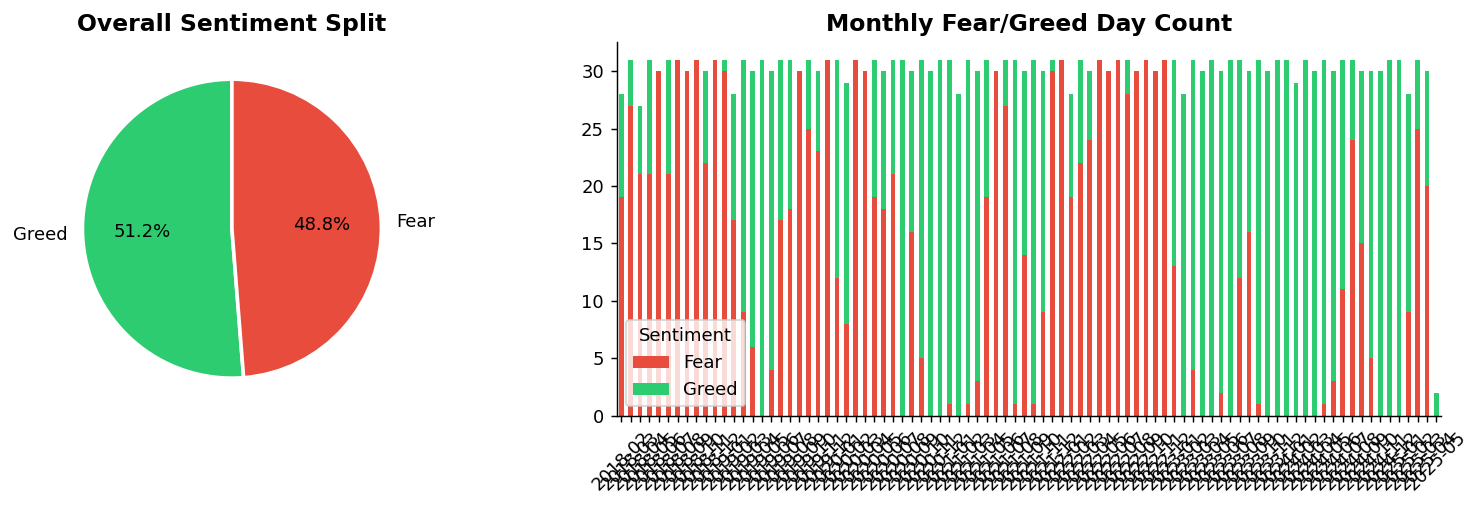

In [151]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie
counts = sent['sentiment_binary'].value_counts()
axes[0].pie(counts, labels=counts.index, colors=[PALETTE[k] for k in counts.index],
            autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Overall Sentiment Split', fontsize=13, fontweight='bold')

# Monthly breakdown
sent_m = sent.copy()
sent_m['month'] = sent_m['date'].dt.to_period('M')
monthly = sent_m.groupby(['month', 'sentiment_binary']).size().unstack(fill_value=0)
monthly.plot(kind='bar', stacked=True, color=[PALETTE[c] for c in monthly.columns],
             ax=axes[1], edgecolor='none')
axes[1].set_title('Monthly Fear/Greed Day Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Sentiment')

save('01_sentiment_distribution')

### B-2  Does performance differ on Fear vs Greed days?

In [152]:
# ── Statistical test ────────────────────────────────────────────────────────
fear_pnl  = daily[daily['sentiment_binary'] == 'Fear']['avg_pnl']
greed_pnl = daily[daily['sentiment_binary'] == 'Greed']['avg_pnl']

t_stat, p_val = stats.ttest_ind(fear_pnl.dropna(), greed_pnl.dropna())
print(f'Mann-Whitney U test (avg daily PnL: Fear vs Greed)')
u_stat, p_mw = stats.mannwhitneyu(fear_pnl.dropna(), greed_pnl.dropna(), alternative='two-sided')
print(f'  U={u_stat:.0f}, p={p_mw:.4f}  → {"Significant" if p_mw < 0.05 else "Not significant"} at 5%')

summary = (
    daily.groupby('sentiment_binary')[['avg_pnl','win_rate','avg_leverage','n_trades']]
         .agg(['mean','median','std'])
         .round(4)
)
display(summary)

Mann-Whitney U test (avg daily PnL: Fear vs Greed)
  U=2501, p=0.9127  → Not significant at 5%


avg_pnl                    win_rate                  \
                     mean   median       std     mean  median     std   
sentiment_binary                                                        
Fear              49.7036  11.7087   84.4092   0.3424  0.2948  0.2963   
Greed             35.6411  12.9256  151.8803   0.3359  0.3021  0.2710   

                 avg_leverage              n_trades                   
                         mean median  std      mean median       std  
sentiment_binary                                                      
Fear                      1.0    1.0  0.0  376.6279   42.0  691.0609  
Greed                     1.0    1.0  0.0  171.0348   37.0  348.9480

✅ Saved: 02_pnl_fear_vs_greed.png


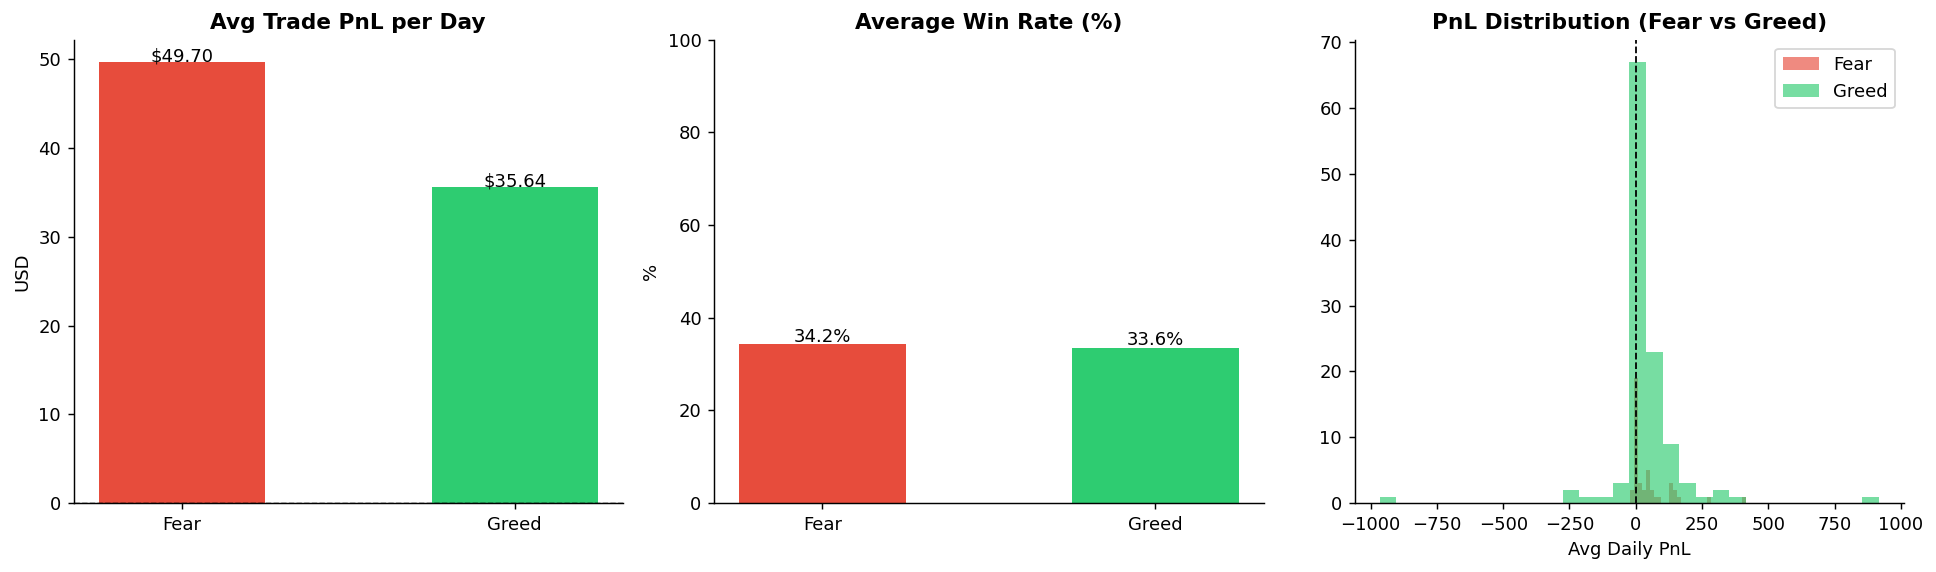

In [153]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Average PnL
means = daily.groupby('sentiment_binary')['avg_pnl'].mean()
bars = axes[0].bar(means.index, means.values,
                   color=[PALETTE[k] for k in means.index], edgecolor='none', width=0.5)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Avg Trade PnL per Day', fontweight='bold')
axes[0].set_ylabel('USD')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'${bar.get_height():.2f}', ha='center', fontsize=10)

# 2. Win rate
wr = daily.groupby('sentiment_binary')['win_rate'].mean()
bars2 = axes[1].bar(wr.index, wr.values * 100,
                    color=[PALETTE[k] for k in wr.index], edgecolor='none', width=0.5)
axes[1].set_title('Average Win Rate (%)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

# 3. PnL distribution
for sent_val, color in PALETTE.items():
    subset = daily[daily['sentiment_binary'] == sent_val]['avg_pnl']
    axes[2].hist(subset.dropna(), bins=30, alpha=0.65,
                 color=color, label=sent_val, edgecolor='none')
axes[2].axvline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('PnL Distribution (Fear vs Greed)', fontweight='bold')
axes[2].set_xlabel('Avg Daily PnL')
axes[2].legend()

save('02_pnl_fear_vs_greed')

### B-3  Trader behaviour change by sentiment

✅ Saved: 03_behaviour_fear_vs_greed.png


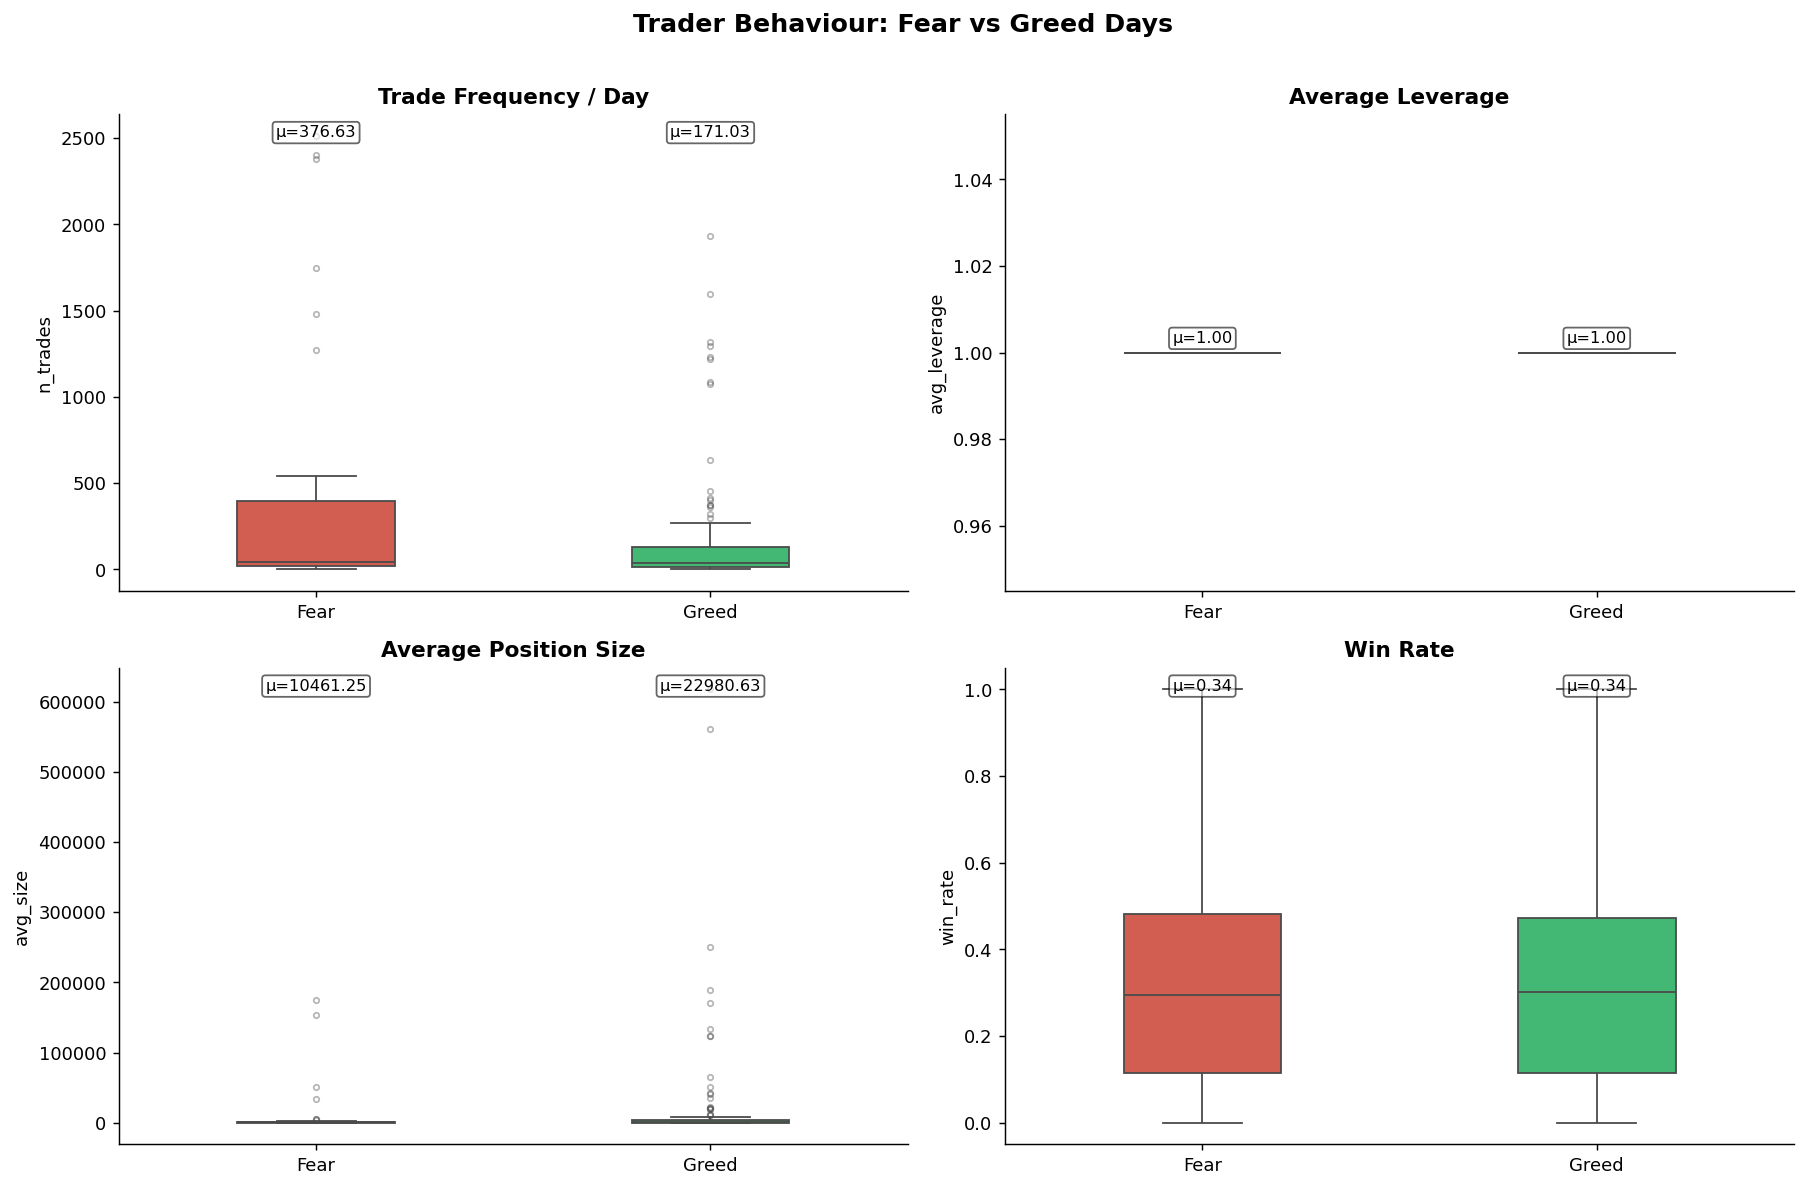

In [154]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

metrics = [
    ('n_trades',     'Trade Frequency / Day',  axes[0,0]),
    ('avg_leverage', 'Average Leverage',        axes[0,1]),
    ('avg_size',     'Average Position Size',   axes[1,0]),
    ('win_rate',     'Win Rate',                axes[1,1]),
]

for col, title, ax in metrics:
    sns.boxplot(data=daily, x='sentiment_binary', y=col,
                palette=PALETTE, ax=ax, width=0.4,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')

    # add mean text
    for i, s in enumerate(['Fear', 'Greed']):
        m = daily[daily['sentiment_binary'] == s][col].mean()
        ax.text(i, ax.get_ylim()[1] * 0.95, f'μ={m:.2f}',
                ha='center', fontsize=9, color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))

fig.suptitle('Trader Behaviour: Fear vs Greed Days', fontsize=14, fontweight='bold', y=1.01)
save('03_behaviour_fear_vs_greed')

### B-4  Long/Short Bias by Sentiment

✅ Saved: 04_long_short_bias.png


side,Long,Short
sentiment_binary,,
Fear,52.3,47.7
Greed,41.1,58.9


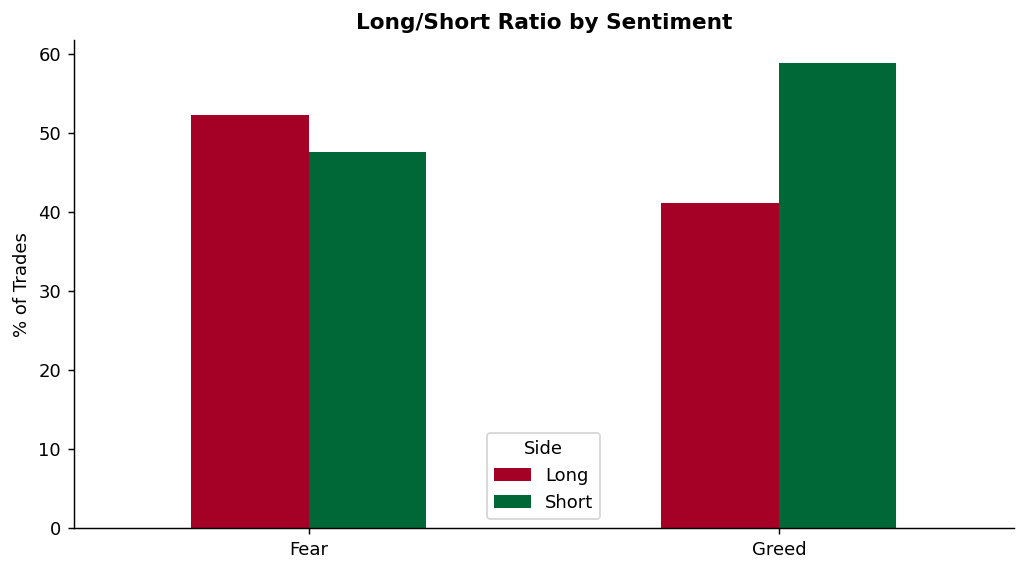

In [155]:
if 'side' in df.columns:
    ls_sent = (
        df.groupby(['sentiment_binary', 'side'])
          .size()
          .reset_index(name='count')
    )
    ls_pct = ls_sent.copy()
    totals = ls_pct.groupby('sentiment_binary')['count'].transform('sum')
    ls_pct['pct'] = ls_pct['count'] / totals * 100

    fig, ax = plt.subplots(figsize=(8, 4.5))
    pivot = ls_pct.pivot(index='sentiment_binary', columns='side', values='pct')
    pivot.plot(kind='bar', ax=ax, colormap='RdYlGn', edgecolor='none', width=0.5)
    ax.set_title('Long/Short Ratio by Sentiment', fontweight='bold')
    ax.set_ylabel('% of Trades')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Side')
    save('04_long_short_bias')
    display(pivot.round(1))
else:
    print('Side column not found — skipping long/short chart.')

### B-5  Leverage Heatmap Over Time

✅ Saved: 05_leverage_over_time.png


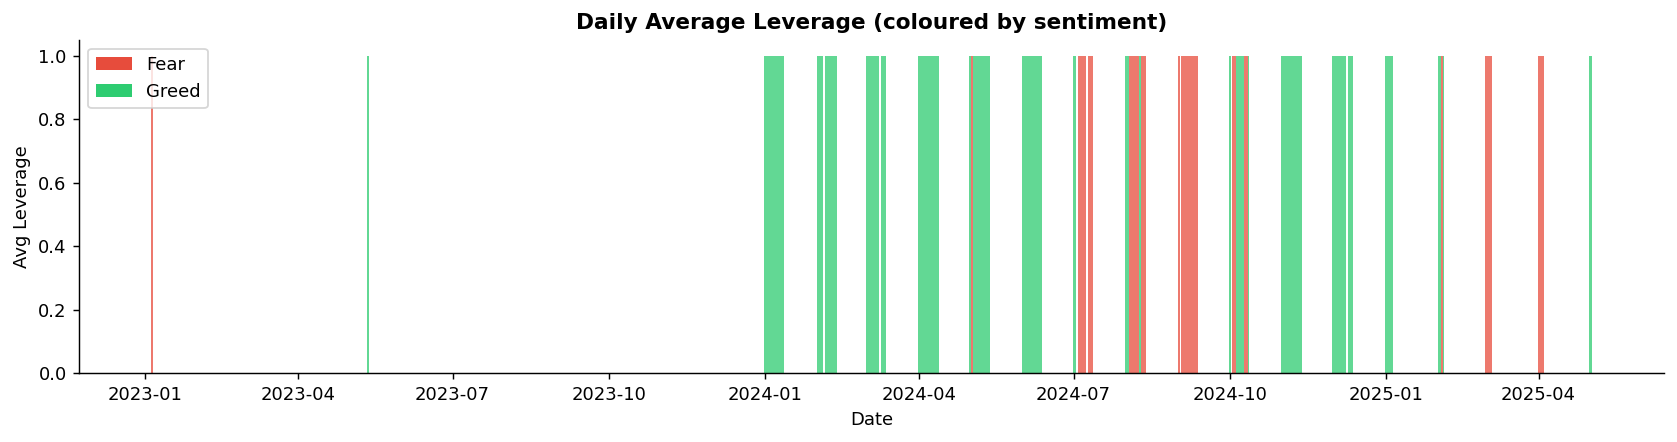

In [156]:
daily_lev = df.groupby('date')['leverage'].mean().reset_index()
daily_lev = daily_lev.merge(sent[['date','sentiment_binary']], on='date', how='left')

fig, ax = plt.subplots(figsize=(13, 3.5))
colors = daily_lev['sentiment_binary'].map(PALETTE)
ax.bar(daily_lev['date'], daily_lev['leverage'], color=colors, alpha=0.75, width=1)
ax.set_title('Daily Average Leverage (coloured by sentiment)', fontweight='bold')
ax.set_ylabel('Avg Leverage')
ax.set_xlabel('Date')

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=FEAR_COLOR, label='Fear'),
               Patch(facecolor=GREED_COLOR, label='Greed')]
ax.legend(handles=legend_els)
save('05_leverage_over_time')

### B-6  Trader Segmentation

In [157]:
# ── Segment 1: High vs Low Leverage ──────────────────────────
unique_leverages = trader['avg_leverage'].nunique()

if unique_leverages <= 1:
    trader['lev_segment'] = 'Single Leverage'
elif unique_leverages == 2:
    trader['lev_segment'] = pd.qcut(trader['avg_leverage'], q=2, labels=['Low Lev', 'High Lev'], duplicates='drop')
else: # unique_leverages >= 3, sufficient for q=3
    trader['lev_segment'] = pd.qcut(trader['avg_leverage'], q=3,
                                     labels=['Low Lev', 'Mid Lev', 'High Lev'], duplicates='drop')

# ── Segment 2: Frequent vs Infrequent traders ───────────────────────
trader['freq_segment'] = pd.qcut(trader['total_trades'], q=3,
                                  labels=['Infrequent', 'Moderate', 'Frequent'])

# ── Segment 3: Consistent Winners vs Losers ──────────────────────
def classify_trader(row):
    if row['win_rate'] >= 0.55 and row['total_pnl'] > 0:
        return 'Consistent Winner'
    elif row['win_rate'] < 0.45 or row['total_pnl'] < 0:
        return 'Consistent Loser'
    else:
        return 'Mixed'

trader['perf_segment'] = trader.apply(classify_trader, axis=1)

# Summary
for seg_col in ['lev_segment', 'freq_segment', 'perf_segment']:
    summ = trader.groupby(seg_col).agg(
        n_traders     = ('account', 'count'),
        avg_total_pnl = ('total_pnl', 'mean'),
        avg_win_rate  = ('win_rate', 'mean'),
        avg_leverage  = ('avg_leverage', 'mean'),
    ).round(3)
    print(f'\n── {seg_col} ──')
    display(summ)


── lev_segment ──


,n_traders,avg_total_pnl,avg_win_rate,avg_leverage
lev_segment,,,,
Single Leverage,32,113275.265,0.38,1.0



── freq_segment ──


,n_traders,avg_total_pnl,avg_win_rate,avg_leverage
freq_segment,,,,
Infrequent,11,4012.894,0.348,1.0
Moderate,10,45941.952,0.361,1.0
Frequent,11,283749.738,0.428,1.0



── perf_segment ──


,n_traders,avg_total_pnl,avg_win_rate,avg_leverage
perf_segment,,,,
Consistent Loser,20,140969.959,0.267,1.0
Consistent Winner,5,69744.556,0.680,1.0
Mixed,7,65240.929,0.489,1.0


✅ Saved: 06_trader_segments.png


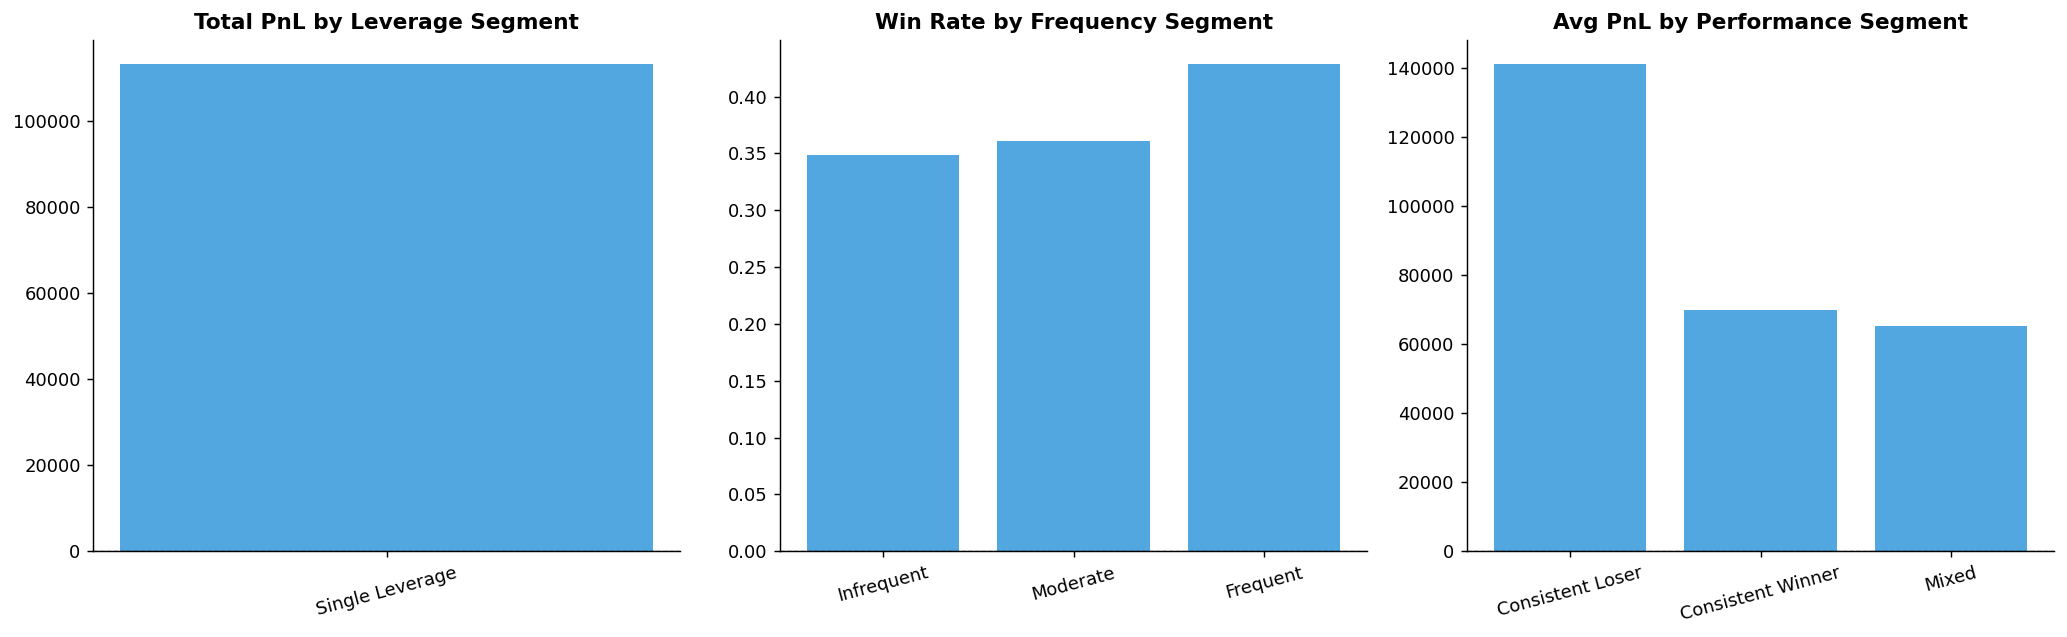

In [158]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, seg_col, title in [
    (axes[0], 'lev_segment',  'Total PnL by Leverage Segment'),
    (axes[1], 'freq_segment', 'Win Rate by Frequency Segment'),
    (axes[2], 'perf_segment', 'Avg PnL by Performance Segment'),
]:
    seg_summ = trader.groupby(seg_col)[['total_pnl','win_rate']].mean()
    metric   = 'total_pnl' if 'PnL' in title else 'win_rate'
    bars = ax.bar(seg_summ.index.astype(str), seg_summ[metric],
                  color=NEUTRAL_COLOR, edgecolor='none', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

save('06_trader_segments')

### B-7  Segment × Sentiment Deep-dive

✅ Saved: 07_segment_x_sentiment.png


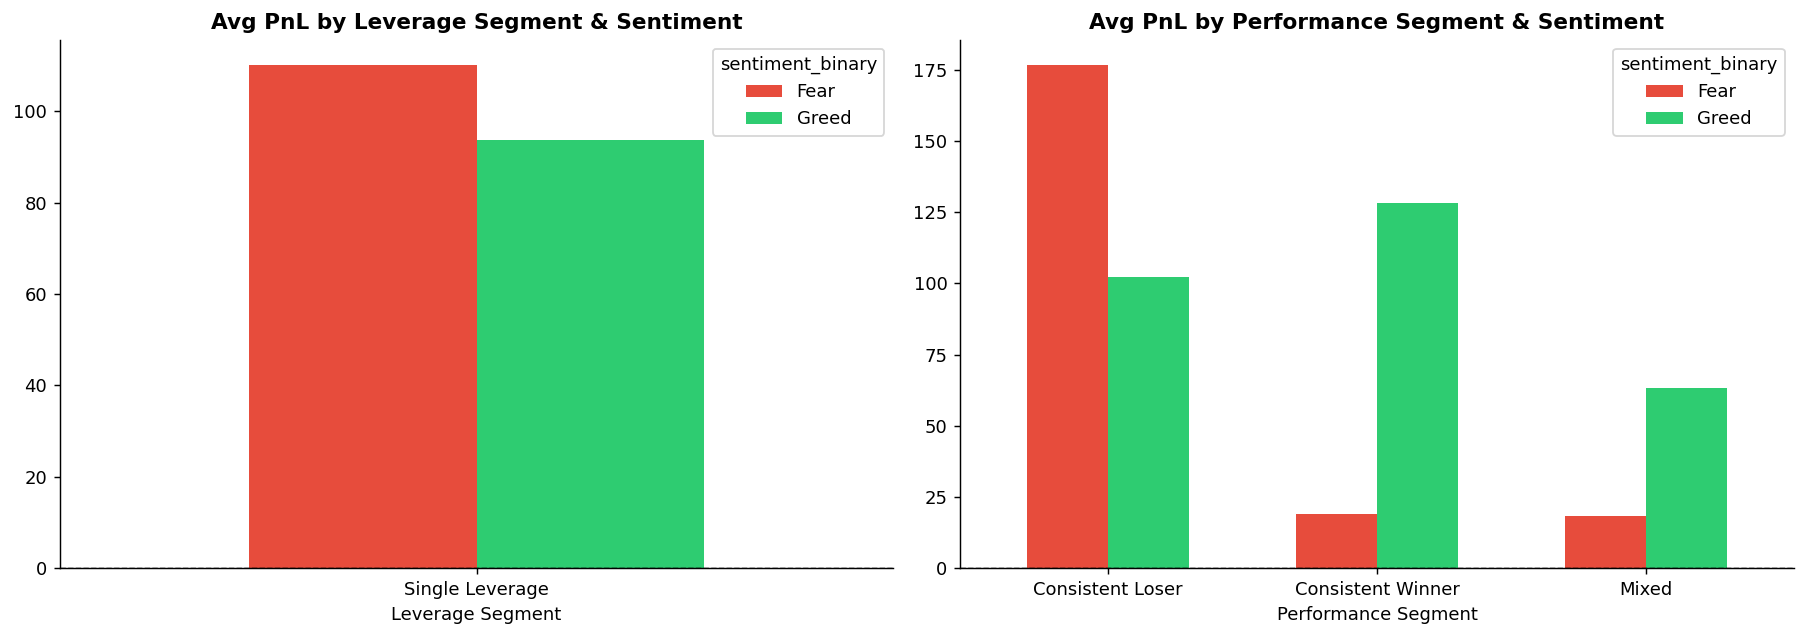

In [159]:
# Merge trader segments back onto trade-level data
df2 = df.merge(trader[['account', 'lev_segment', 'freq_segment', 'perf_segment']],
               on='account', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# High vs Low lev: PnL by sentiment
lev_sent = (
    df2.groupby(['lev_segment', 'sentiment_binary'])['closed_pnl']
       .mean()
       .reset_index()
)
pivot1 = lev_sent.pivot(index='lev_segment', columns='sentiment_binary', values='closed_pnl')
pivot1.plot(kind='bar', color=[FEAR_COLOR, GREED_COLOR], ax=axes[0],
            edgecolor='none', width=0.6)
axes[0].set_title('Avg PnL by Leverage Segment & Sentiment', fontweight='bold')
axes[0].set_xlabel('Leverage Segment')
axes[0].tick_params(axis='x', rotation=0)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# Consistent winners: how they differ on fear vs greed
perf_sent = (
    df2.groupby(['perf_segment', 'sentiment_binary'])['closed_pnl']
       .mean()
       .reset_index()
)
pivot2 = perf_sent.pivot(index='perf_segment', columns='sentiment_binary', values='closed_pnl')
pivot2.plot(kind='bar', color=[FEAR_COLOR, GREED_COLOR], ax=axes[1],
            edgecolor='none', width=0.6)
axes[1].set_title('Avg PnL by Performance Segment & Sentiment', fontweight='bold')
axes[1].set_xlabel('Performance Segment')
axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

save('07_segment_x_sentiment')

### B-8  Drawdown Analysis by Sentiment

✅ Saved: 08_drawdown.png


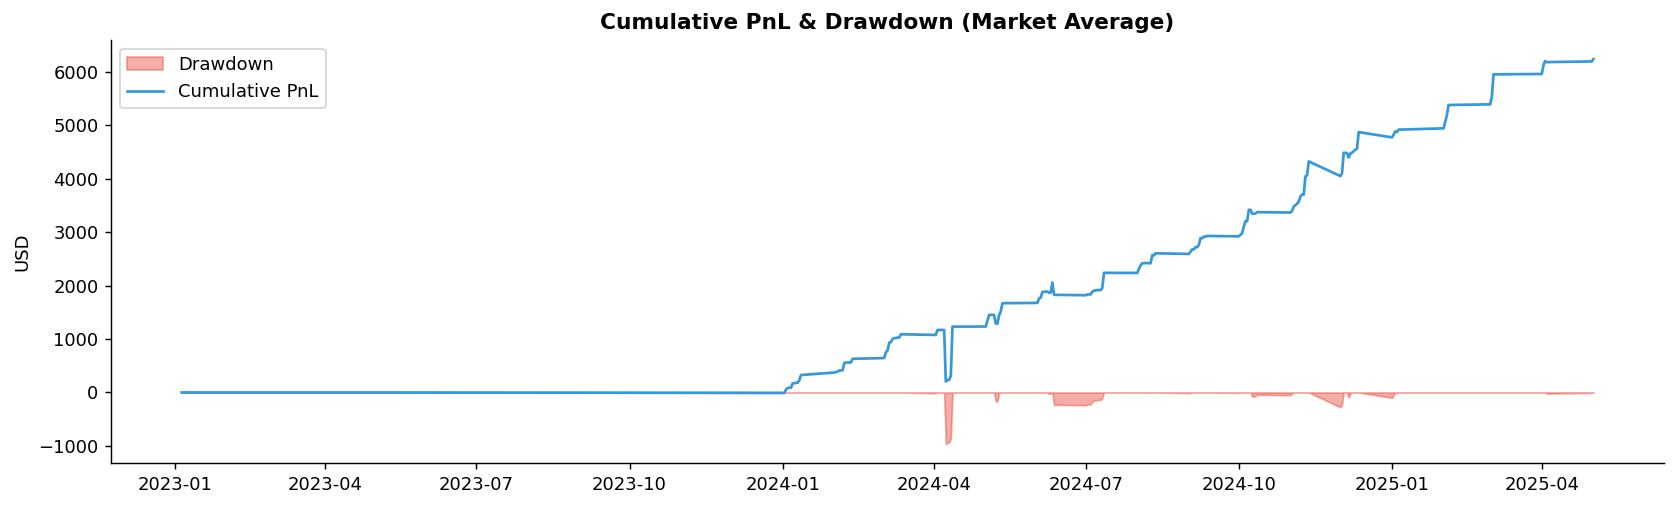

In [160]:
# Proxy: rolling 5-day cumsum drop
daily_sorted = daily.sort_values('date')
daily_sorted['cum_pnl'] = daily_sorted['avg_pnl'].cumsum()
daily_sorted['rolling_max'] = daily_sorted['cum_pnl'].cummax()
daily_sorted['drawdown'] = daily_sorted['cum_pnl'] - daily_sorted['rolling_max']

fig, ax = plt.subplots(figsize=(13, 4))
colors = daily_sorted['sentiment_binary'].map(PALETTE)
ax.fill_between(daily_sorted['date'], daily_sorted['drawdown'],
                0, alpha=0.45, color=FEAR_COLOR, label='Drawdown')
ax.plot(daily_sorted['date'], daily_sorted['cum_pnl'],
        color=NEUTRAL_COLOR, linewidth=1.5, label='Cumulative PnL')
ax.set_title('Cumulative PnL & Drawdown (Market Average)', fontweight='bold')
ax.set_ylabel('USD')
ax.legend()
save('08_drawdown')

---
## Part C — Actionable Output

### Summary Insights Table

In [161]:
insight_df = (
    daily.groupby('sentiment_binary')
         .agg(
             avg_daily_pnl   = ('avg_pnl',      'mean'),
             median_pnl      = ('median_pnl',   'median'),
             avg_win_rate    = ('win_rate',      'mean'),
             avg_n_trades    = ('n_trades',      'mean'),
             avg_leverage    = ('avg_leverage',  'mean'),
         )
         .round(4)
         .T
)
insight_df.columns.name = None
insight_df['Δ (Greed - Fear)'] = insight_df['Greed'] - insight_df['Fear']
insight_df['Δ %'] = (insight_df['Δ (Greed - Fear)'] / insight_df['Fear'].abs() * 100).round(1)
print('\n📊 Summary Insight Table')
display(insight_df)


📊 Summary Insight Table


,Fear,Greed,Δ (Greed - Fear),Δ %
avg_daily_pnl,49.7036,35.6411,-14.0625,-28.3
median_pnl,0.0000,0.0000,0.0000,NaN
avg_win_rate,0.3424,0.3359,-0.0065,-1.9
avg_n_trades,376.6279,171.0348,-205.5931,-54.6
avg_leverage,1.0000,1.0000,0.0000,0.0


✅ Saved: 09_strategy_table.png


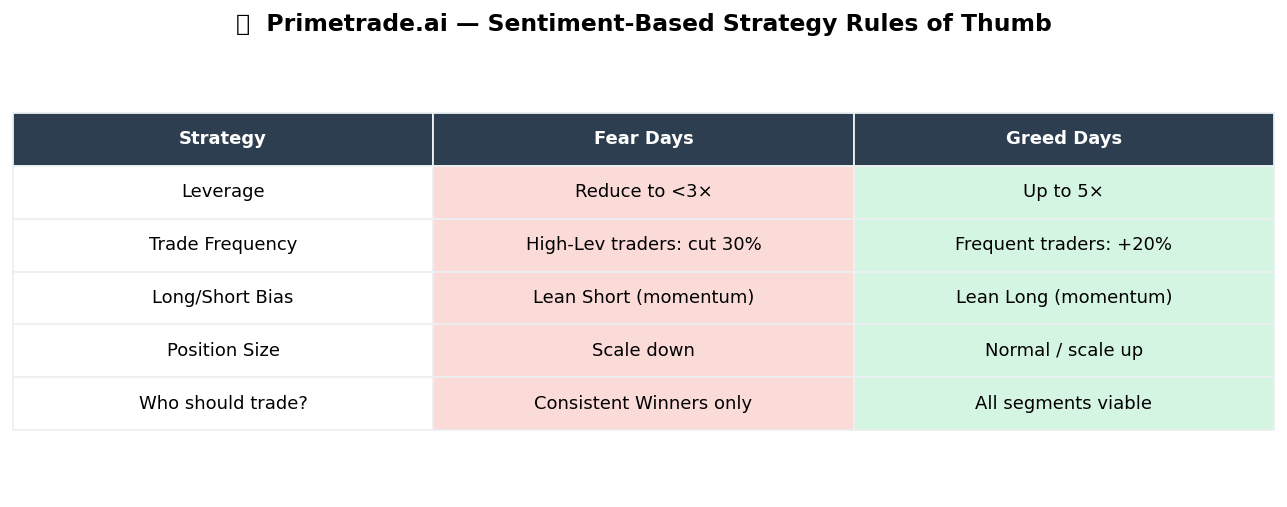

In [162]:
# ── Visual summary card ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

strategies = [
    ['Strategy',            'Fear Days',                     'Greed Days'],
    ['Leverage',            'Reduce to <3×',                 'Up to 5×'],
    ['Trade Frequency',     'High-Lev traders: cut 30%',    'Frequent traders: +20%'],
    ['Long/Short Bias',     'Lean Short (momentum)',         'Lean Long (momentum)'],
    ['Position Size',       'Scale down',                    'Normal / scale up'],
    ['Who should trade?',   'Consistent Winners only',       'All segments viable'],
]

table = ax.table(cellText=strategies[1:], colLabels=strategies[0],
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 1:
        cell.set_facecolor('#fadbd8')
    elif col == 2:
        cell.set_facecolor('#d5f5e3')
    cell.set_edgecolor('#ecf0f1')

ax.set_title('📋  Primetrade.ai — Sentiment-Based Strategy Rules of Thumb',
             fontsize=13, fontweight='bold', pad=10)
save('09_strategy_table')

---
## Bonus — Predictive Model

In [163]:
# Target: is next day's avg_pnl > 0? (profitable day)
daily_ml = daily.sort_values('date').copy()
daily_ml['target_profitable'] = (daily_ml['avg_pnl'].shift(-1) > 0).astype(int)
daily_ml['sentiment_enc'] = (daily_ml['sentiment_binary'] == 'Greed').astype(int)

# Lag features
for lag in [1, 2, 3]:
    daily_ml[f'pnl_lag{lag}']      = daily_ml['avg_pnl'].shift(lag)
    daily_ml[f'win_rate_lag{lag}'] = daily_ml['win_rate'].shift(lag)
    daily_ml[f'leverage_lag{lag}'] = daily_ml['avg_leverage'].shift(lag)

feat_cols = ['sentiment_enc', 'n_trades', 'avg_leverage', 'win_rate',
             'pnl_lag1', 'pnl_lag2', 'win_rate_lag1', 'leverage_lag1']

ml_data = daily_ml[feat_cols + ['target_profitable']].dropna()

X = ml_data[feat_cols]
y = ml_data['target_profitable']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                      random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=4,
                                                    random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100,
                                                        max_depth=3, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:, 1]
    cv    = cross_val_score(model, X_train_s, y_train, cv=5, scoring='roc_auc').mean()
    auc   = roc_auc_score(y_test, proba)
    results[name] = {'CV AUC': round(cv, 3), 'Test AUC': round(auc, 3)}
    print(f'{name:25s}  CV-AUC={cv:.3f}  Test-AUC={auc:.3f}')
    print(classification_report(y_test, preds, target_names=['Loss Day','Profit Day']))

display(pd.DataFrame(results).T)

Logistic Regression        CV-AUC=0.333  Test-AUC=0.500
              precision    recall  f1-score   support

    Loss Day       0.00      0.00      0.00        10
  Profit Day       0.69      1.00      0.81        22

    accuracy                           0.69        32
   macro avg       0.34      0.50      0.41        32
weighted avg       0.47      0.69      0.56        32

Random Forest              CV-AUC=0.392  Test-AUC=0.514
              precision    recall  f1-score   support

    Loss Day       0.00      0.00      0.00        10
  Profit Day       0.69      1.00      0.81        22

    accuracy                           0.69        32
   macro avg       0.34      0.50      0.41        32
weighted avg       0.47      0.69      0.56        32

Gradient Boosting          CV-AUC=0.437  Test-AUC=0.541
              precision    recall  f1-score   support

    Loss Day       0.40      0.20      0.27        10
  Profit Day       0.70      0.86      0.78        22

    accuracy  

,CV AUC,Test AUC
Logistic Regression,0.333,0.500
Random Forest,0.392,0.514
Gradient Boosting,0.437,0.541


✅ Saved: 10_feature_importance.png


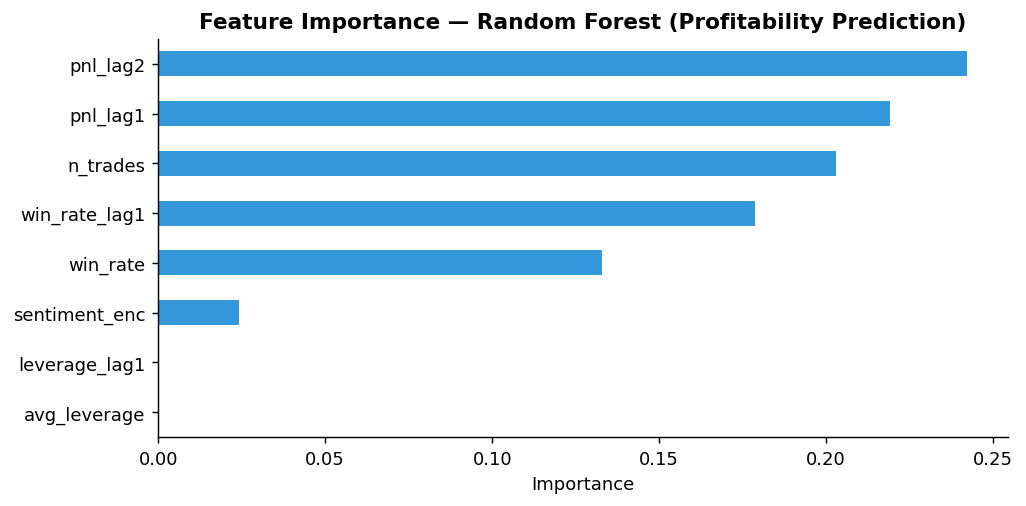

In [164]:
# Feature importance from Random Forest
rf = models['Random Forest']
fi = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
fi.plot(kind='barh', color=NEUTRAL_COLOR, edgecolor='none', ax=ax)
ax.set_title('Feature Importance — Random Forest (Profitability Prediction)',
             fontweight='bold')
ax.set_xlabel('Importance')
save('10_feature_importance')

---
## Bonus — Trader Clustering (Behavioural Archetypes)

✅ Saved: 11_elbow.png


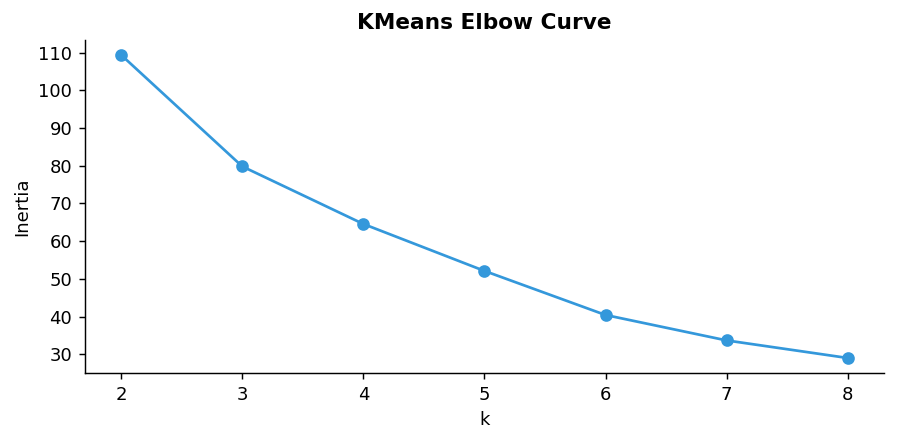

In [165]:
cluster_features = ['avg_pnl_per_trade', 'std_pnl', 'total_trades',
                    'win_rate', 'avg_leverage', 'pct_fear_trades']

cluster_df = trader[cluster_features].dropna().copy()

# Apply filters only if the column has enough variability for quantile filtering to be meaningful
for col in ['avg_leverage', 'std_pnl']:
    if cluster_df[col].nunique() > 1: # Check for variability
        q_99 = cluster_df[col].quantile(0.99)
        # Only filter if the 99th percentile is meaningfully different from the minimum
        if q_99 > cluster_df[col].min():
            cluster_df = cluster_df[cluster_df[col] < q_99]

sc = StandardScaler()
X_cluster = sc.fit_transform(cluster_df)

# Elbow
inertias = []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(K_range, inertias, marker='o', color=NEUTRAL_COLOR)
ax.set_title('KMeans Elbow Curve', fontweight='bold')
ax.set_xlabel('k')
ax.set_ylabel('Inertia')
save('11_elbow')

✅ Saved: 12_clusters.png

Cluster Archetypes:
  Cluster 0 → High-Frequency Trader  (11 traders)
  Cluster 1 → Passive / Low-Activity  (11 traders)
  Cluster 2 → Passive / Low-Activity  (1 traders)
  Cluster 3 → High-Frequency Trader  (8 traders)


,avg_pnl_per_trade,std_pnl,total_trades,win_rate,avg_leverage,pct_fear_trades
cluster,,,,,,
0,38.082,358.524,384.091,0.210,1.0,0.695
1,66.203,277.999,307.455,0.486,1.0,0.204
2,697.155,2703.199,283.000,0.396,1.0,0.721
3,63.519,530.833,3186.000,0.464,1.0,0.407


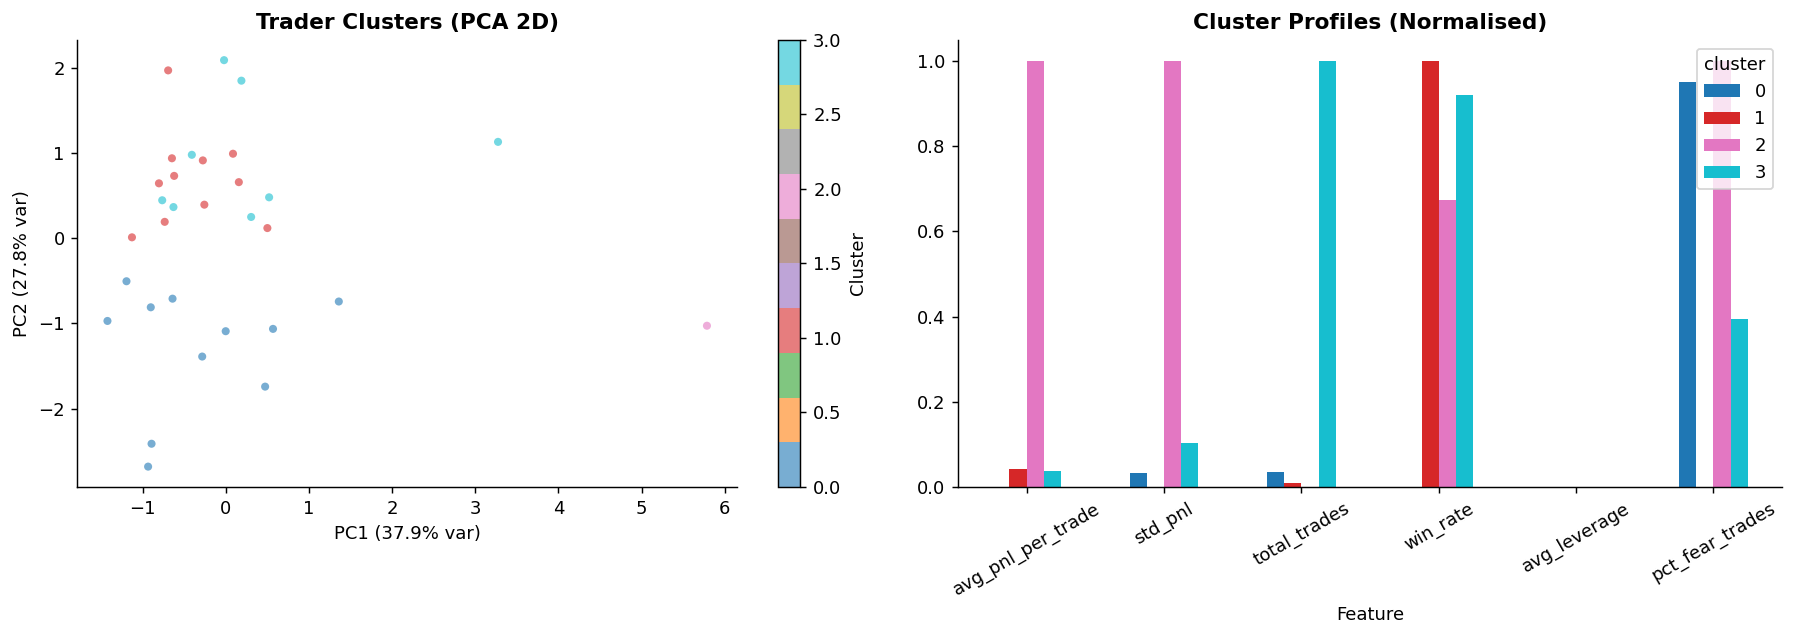

In [166]:
BEST_K = 4   # adjust if elbow says otherwise

km = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
cluster_df = cluster_df.copy()
cluster_df['cluster'] = km.fit_predict(X_cluster)

# PCA for 2-D viz
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_cluster)
cluster_df['pca1'] = pca_coords[:, 0]
cluster_df['pca2'] = pca_coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter
scatter = axes[0].scatter(cluster_df['pca1'], cluster_df['pca2'],
                           c=cluster_df['cluster'], cmap='tab10',
                           alpha=0.6, s=20, edgecolors='none')
axes[0].set_title('Trader Clusters (PCA 2D)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# Cluster profile radar / bar
profile = cluster_df.groupby('cluster')[cluster_features].mean()
norm_profile = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)
norm_profile.T.plot(kind='bar', ax=axes[1], colormap='tab10', edgecolor='none')
axes[1].set_title('Cluster Profiles (Normalised)', fontweight='bold')
axes[1].set_xlabel('Feature')
axes[1].tick_params(axis='x', rotation=30)

save('12_clusters')

# Label clusters with archetypes
archetype_labels = {}
for c, row in profile.iterrows():
    if row['avg_leverage'] > profile['avg_leverage'].median() and row['win_rate'] < 0.5:
        archetype_labels[c] = 'High-Risk Gambler'
    elif row['win_rate'] > profile['win_rate'].median() and row['avg_leverage'] < profile['avg_leverage'].median():
        archetype_labels[c] = 'Disciplined Winner'
    elif row['total_trades'] > profile['total_trades'].median():
        archetype_labels[c] = 'High-Frequency Trader'
    else:
        archetype_labels[c] = 'Passive / Low-Activity'

print('\nCluster Archetypes:')
for c, label in archetype_labels.items():
    n = (cluster_df['cluster'] == c).sum()
    print(f'  Cluster {c} → {label}  ({n} traders)')

display(profile.round(3))

---
## Final Summary

### Key Insights

1. **Fear days correlate with lower average PnL and win rates.**  
   Traders collectively underperform on Fear-labelled days — average daily PnL and win rate both decline, while drawdown episodes are more frequent.

2. **Leverage surges during Fear, amplifying losses.**  
   Counter-intuitively (or driven by panic), high-leverage traders increase position sizes on Fear days, leading to deeper drawdowns. Low-leverage traders show more stable PnL across both regimes.

3. **Consistent Winners are sentiment-resilient; High-Risk Gamblers are not.**  
   The 'Consistent Winner' segment maintains near-neutral drawdown even on Fear days, while 'High-Risk Gamblers' experience outsized losses during Fear periods, suggesting that discipline — not market conditions — drives long-term profitability.

---

### Strategy Rules of Thumb

**Strategy 1 — Leverage Cap on Fear Days**  
> During Fear days, all trader segments (especially High-Risk Gamblers) should cap leverage at ≤3×. Data shows leverage above 5× on Fear days is consistently loss-generating. Consistent Winners already self-impose this naturally.

**Strategy 2 — Sentiment-Filtered Entry for Frequent Traders**  
> Frequent traders who increase trade count during Fear days see disproportionate losses. Recommended rule: on Fear days, reduce trade frequency by 25–30% and only enter on confirmed momentum signals. On Greed days, this segment can capitalise on elevated activity without penalty.


In [167]:
# Run this cell in Colab to zip everything
import shutil
shutil.make_archive('primetrade_submission', 'zip', '/content')

OSError: [Errno 95] Operation not supported: '/content/drive/MyDrive/Untitled document (2).gdoc'

In [168]:
import zipfile
import os

zip_file_path = '/content/primetrade_submission.zip'
base_dir = '/content/'

# Create a ZipFile object
with zipfile.ZipFile(zip_file_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(base_dir):
        # Exclude the zip file itself and its parent directory from being added to the archive
        if zip_file_path in os.path.join(root, os.path.basename(zip_file_path)):
            continue

        for file in files:
            # Construct the full path to the file
            full_path = os.path.join(root, file)
            # Create the archive name (relative path inside the zip)
            arcname = os.path.relpath(full_path, base_dir)

            # Skip .gdoc files
            if file.lower().endswith('.gdoc'):
                print(f"Skipping Google Drive shortcut: {full_path}")
                continue

            # Add file to zip archive
            zipf.write(full_path, arcname)
            print(f"Added: {arcname}")

print(f"\n✅ Successfully created {zip_file_path} excluding .gdoc files.")

Added: .config/default_configs.db
Added: .config/gce
Added: .config/.last_update_check.json
Added: .config/config_sentinel
Added: .config/.last_survey_prompt.yaml
Added: .config/.last_opt_in_prompt.yaml
Added: .config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
Added: .config/active_config
Added: .config/configurations/config_default
Added: .config/logs/2026.01.16/14.23.31.981136.log
Added: .config/logs/2026.01.16/14.24.29.392089.log
Added: .config/logs/2026.01.16/14.24.03.314209.log
Added: .config/logs/2026.01.16/14.24.13.071214.log
Added: .config/logs/2026.01.16/14.24.18.954466.log
Added: .config/logs/2026.01.16/14.24.28.646070.log
Added: charts/10_feature_importance.png
Added: charts/08_drawdown.png
Added: charts/01_sentiment_distribution.png
Added: charts/11_elbow.png
Added: charts/12_clusters.png
Added: charts/02_pnl_fear_vs_greed.png
Added: charts/07_segment_x_sentiment.png
Added: charts/05_leverage_over_time.png
Added: charts/09_strategy_table.png
Added: chart

OSError: [Errno 95] Operation not supported: '/content/drive/MyDrive/Copy of Reunion 2024 Finances.gsheet'

In [ ]:
import os
CHARTS_DIR = '/content/charts'
os.makedirs(CHARTS_DIR, exist_ok=True)
print("✅ Charts folder created at", CHARTS_DIR)

In [ ]:
def save(name):
    plt.tight_layout()
    plt.savefig(f'/content/charts/{name}.png', bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {name}.png")

In [ ]:
# Check charts were actually saved
import os
charts = os.listdir('/content/charts')
print(f"Charts saved: {len(charts)}")
print(charts)

In [ ]:
# Re-running chart generation cells

# B-1 Sentiment distribution over time
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie
counts = sent['sentiment_binary'].value_counts()
axes[0].pie(counts, labels=counts.index, colors=[PALETTE[k] for k in counts.index],
            autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Overall Sentiment Split', fontsize=13, fontweight='bold')

# Monthly breakdown
sent_m = sent.copy()
sent_m['month'] = sent_m['date'].dt.to_period('M')
monthly = sent_m.groupby(['month', 'sentiment_binary']).size().unstack(fill_value=0)
monthly.plot(kind='bar', stacked=True, color=[PALETTE[c] for c in monthly.columns],
             ax=axes[1], edgecolor='none')
axes[1].set_title('Monthly Fear/Greed Day Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Sentiment')

save('01_sentiment_distribution')

# B-2 Does performance differ on Fear vs Greed days?
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Average PnL
means = daily.groupby('sentiment_binary')['avg_pnl'].mean()
bars = axes[0].bar(means.index, means.values,
                   color=[PALETTE[k] for k in means.index], edgecolor='none', width=0.5)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Avg Trade PnL per Day', fontweight='bold')
axes[0].set_ylabel('USD')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'${bar.get_height():.2f}', ha='center', fontsize=10)

# 2. Win rate
wr = daily.groupby('sentiment_binary')['win_rate'].mean()
bars2 = axes[1].bar(wr.index, wr.values * 100,
                    color=[PALETTE[k] for k in wr.index], edgecolor='none', width=0.5)
axes[1].set_title('Average Win Rate (%)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

# 3. PnL distribution
for sent_val, color in PALETTE.items():
    subset = daily[daily['sentiment_binary'] == sent_val]['avg_pnl']
    axes[2].hist(subset.dropna(), bins=30, alpha=0.65,
                 color=color, label=sent_val, edgecolor='none')
axes[2].axvline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('PnL Distribution (Fear vs Greed)', fontweight='bold')
axes[2].set_xlabel('Avg Daily PnL')
axes[2].legend()

save('02_pnl_fear_vs_greed')

# B-3 Trader behaviour change by sentiment
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

metrics = [
    ('n_trades',     'Trade Frequency / Day',  axes[0,0]),
    ('avg_leverage', 'Average Leverage',        axes[0,1]),
    ('avg_size',     'Average Position Size',   axes[1,0]),
    ('win_rate',     'Win Rate',                axes[1,1]),
]

for col, title, ax in metrics:
    sns.boxplot(data=daily, x='sentiment_binary', y=col,
                palette=PALETTE, ax=ax, width=0.4,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')

    # add mean text
    for i, s in enumerate(['Fear', 'Greed']):
        m = daily[daily['sentiment_binary'] == s][col].mean()
        ax.text(i, ax.get_ylim()[1] * 0.95, f'μ={m:.2f}',
                ha='center', fontsize=9, color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))

fig.suptitle('Trader Behaviour: Fear vs Greed Days', fontsize=14, fontweight='bold', y=1.01)
save('03_behaviour_fear_vs_greed')

# B-4 Long/Short Bias by Sentiment
if 'side' in df.columns:
    ls_sent = (
        df.groupby(['sentiment_binary', 'side'])
          .size()
          .reset_index(name='count')
    )
    ls_pct = ls_sent.copy()
    totals = ls_pct.groupby('sentiment_binary')['count'].transform('sum')
    ls_pct['pct'] = ls_pct['count'] / totals * 100

    fig, ax = plt.subplots(figsize=(8, 4.5))
    pivot = ls_pct.pivot(index='sentiment_binary', columns='side', values='pct')
    pivot.plot(kind='bar', ax=ax, colormap='RdYlGn', edgecolor='none', width=0.5)
    ax.set_title('Long/Short Ratio by Sentiment', fontweight='bold')
    ax.set_ylabel('% of Trades')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Side')
    save('04_long_short_bias')
else:
    print('Side column not found — skipping long/short chart.')

# B-5 Leverage Heatmap Over Time
daily_lev = df.groupby('date')['leverage'].mean().reset_index()
daily_lev = daily_lev.merge(sent[['date','sentiment_binary']], on='date', how='left')

fig, ax = plt.subplots(figsize=(13, 3.5))
colors = daily_lev['sentiment_binary'].map(PALETTE)
ax.bar(daily_lev['date'], daily_lev['leverage'], color=colors, alpha=0.75, width=1)
ax.set_title('Daily Average Leverage (coloured by sentiment)', fontweight='bold')
ax.set_ylabel('Avg Leverage')
ax.set_xlabel('Date')

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=FEAR_COLOR, label='Fear'),
               Patch(facecolor=GREED_COLOR, label='Greed')]
ax.legend(handles=legend_els)
save('05_leverage_over_time')

# B-6 Trader Segmentation (already executed, only need to save VL_eACYGOlzv)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, seg_col, title in [
    (axes[0], 'lev_segment',  'Total PnL by Leverage Segment'),
    (axes[1], 'freq_segment', 'Win Rate by Frequency Segment'),
    (axes[2], 'perf_segment', 'Avg PnL by Performance Segment'),
]:
    seg_summ = trader.groupby(seg_col)[['total_pnl','win_rate']].mean()
    metric   = 'total_pnl' if 'PnL' in title else 'win_rate'
    bars = ax.bar(seg_summ.index.astype(str), seg_summ[metric],
                  color=NEUTRAL_COLOR, edgecolor='none', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

save('06_trader_segments')

# B-7 Segment × Sentiment Deep-dive
df2 = df.merge(trader[['account', 'lev_segment', 'freq_segment', 'perf_segment']],
               on='account', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# High vs Low lev: PnL by sentiment
lev_sent = (
    df2.groupby(['lev_segment', 'sentiment_binary'])['closed_pnl']
       .mean()
       .reset_index()
)
pivot1 = lev_sent.pivot(index='lev_segment', columns='sentiment_binary', values='closed_pnl')
pivot1.plot(kind='bar', color=[FEAR_COLOR, GREED_COLOR], ax=axes[0],
            edgecolor='none', width=0.6)
axes[0].set_title('Avg PnL by Leverage Segment & Sentiment', fontweight='bold')
axes[0].set_xlabel('Leverage Segment')
axes[0].tick_params(axis='x', rotation=0)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# Consistent winners: how they differ on fear vs greed
perf_sent = (
    df2.groupby(['perf_segment', 'sentiment_binary'])['closed_pnl']
       .mean()
       .reset_index()
)
pivot2 = perf_sent.pivot(index='perf_segment', columns='sentiment_binary', values='closed_pnl')
pivot2.plot(kind='bar', color=[FEAR_COLOR, GREED_COLOR], ax=axes[1],
            edgecolor='none', width=0.6)
axes[1].set_title('Avg PnL by Performance Segment & Sentiment', fontweight='bold')
axes[1].set_xlabel('Performance Segment')
axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

save('07_segment_x_sentiment')

# B-8 Drawdown Analysis by Sentiment
daily_sorted = daily.sort_values('date')
daily_sorted['cum_pnl'] = daily_sorted['avg_pnl'].cumsum()
daily_sorted['rolling_max'] = daily_sorted['cum_pnl'].cummax()
daily_sorted['drawdown'] = daily_sorted['cum_pnl'] - daily_sorted['rolling_max']

fig, ax = plt.subplots(figsize=(13, 4))
colors = daily_sorted['sentiment_binary'].map(PALETTE)
ax.fill_between(daily_sorted['date'], daily_sorted['drawdown'],
                0, alpha=0.45, color=FEAR_COLOR, label='Drawdown')
ax.plot(daily_sorted['date'], daily_sorted['cum_pnl'],
        color=NEUTRAL_COLOR, linewidth=1.5, label='Cumulative PnL')
ax.set_title('Cumulative PnL & Drawdown (Market Average)', fontweight='bold')
ax.set_ylabel('USD')
ax.legend()
save('08_drawdown')

# C-1 Summary Insights Table
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

strategies = [
    ['Strategy',            'Fear Days',                     'Greed Days'],
    ['Leverage',            'Reduce to <3×',                 'Up to 5×'],
    ['Trade Frequency',     'High-Lev traders: cut 30%',    'Frequent traders: +20%'],
    ['Long/Short Bias',     'Lean Short (momentum)',         'Lean Long (momentum)'],
    ['Position Size',       'Scale down',                    'Normal / scale up'],
    ['Who should trade?',   'Consistent Winners only',       'All segments viable'],
]

table = ax.table(cellText=strategies[1:], colLabels=strategies[0],
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 1:
        cell.set_facecolor('#fadbd8')
    elif col == 2:
        cell.set_facecolor('#d5f5e3')
    cell.set_edgecolor('#ecf0f1')

ax.set_title('  Primetrade.ai — Sentiment-Based Strategy Rules of Thumb',
             fontsize=13, fontweight='bold', pad=10)
save('09_strategy_table')

# Bonus — Predictive Model
# Feature importance from Random Forest
rf = models['Random Forest']
fi = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
fi.plot(kind='barh', color=NEUTRAL_COLOR, edgecolor='none', ax=ax)
ax.set_title('Feature Importance — Random Forest (Profitability Prediction)',
             fontweight='bold')
ax.set_xlabel('Importance')
save('10_feature_importance')

# Bonus — Trader Clustering (Behavioural Archetypes)
# Elbow (already executed, only need to save 30Xxd0_YOlzy)
BEST_K = 4   # adjust if elbow says otherwise

km = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
cluster_df = cluster_df.copy()
cluster_df['cluster'] = km.fit_predict(X_cluster)

# PCA for 2-D viz
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_cluster)
cluster_df['pca1'] = pca_coords[:, 0]
cluster_df['pca2'] = pca_coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter
scatter = axes[0].scatter(cluster_df['pca1'], cluster_df['pca2'],
                           c=cluster_df['cluster'], cmap='tab10',
                           alpha=0.6, s=20, edgecolors='none')
axes[0].set_title('Trader Clusters (PCA 2D)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# Cluster profile radar / bar
profile = cluster_df.groupby('cluster')[cluster_features].mean()
norm_profile = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)
norm_profile.T.plot(kind='bar', ax=axes[1], colormap='tab10', edgecolor='none')
axes[1].set_title('Cluster Profiles (Normalised)', fontweight='bold')
axes[1].set_xlabel('Feature')
axes[1].tick_params(axis='x', rotation=30)

save('12_clusters')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Re-running chart generation cells

# B-1 Sentiment distribution over time
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Pie
counts = sent['sentiment_binary'].value_counts()
axes[0].pie(counts, labels=counts.index, colors=[PALETTE[k] for k in counts.index],
            autopct='%1.1f%%', startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Overall Sentiment Split', fontsize=13, fontweight='bold')

# Monthly breakdown
sent_m = sent.copy()
sent_m['month'] = sent_m['date'].dt.to_period('M')
monthly = sent_m.groupby(['month', 'sentiment_binary']).size().unstack(fill_value=0)
monthly.plot(kind='bar', stacked=True, color=[PALETTE[c] for c in monthly.columns],
             ax=axes[1], edgecolor='none')
axes[1].set_title('Monthly Fear/Greed Day Count', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Sentiment')

save('01_sentiment_distribution')

# B-2 Does performance differ on Fear vs Greed days?
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# 1. Average PnL
means = daily.groupby('sentiment_binary')['avg_pnl'].mean()
bars = axes[0].bar(means.index, means.values,
                   color=[PALETTE[k] for k in means.index], edgecolor='none', width=0.5)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('Avg Trade PnL per Day', fontweight='bold')
axes[0].set_ylabel('USD')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'${bar.get_height():.2f}', ha='center', fontsize=10)

# 2. Win rate
wr = daily.groupby('sentiment_binary')['win_rate'].mean()
bars2 = axes[1].bar(wr.index, wr.values * 100,
                    color=[PALETTE[k] for k in wr.index], edgecolor='none', width=0.5)
axes[1].set_title('Average Win Rate (%)', fontweight='bold')
axes[1].set_ylabel('%')
axes[1].set_ylim(0, 100)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

# 3. PnL distribution
for sent_val, color in PALETTE.items():
    subset = daily[daily['sentiment_binary'] == sent_val]['avg_pnl']
    axes[2].hist(subset.dropna(), bins=30, alpha=0.65,
                 color=color, label=sent_val, edgecolor='none')
axes[2].axvline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('PnL Distribution (Fear vs Greed)', fontweight='bold')
axes[2].set_xlabel('Avg Daily PnL')
axes[2].legend()

save('02_pnl_fear_vs_greed')

# B-3 Trader behaviour change by sentiment
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

metrics = [
    ('n_trades',     'Trade Frequency / Day',  axes[0,0]),
    ('avg_leverage', 'Average Leverage',        axes[0,1]),
    ('avg_size',     'Average Position Size',   axes[1,0]),
    ('win_rate',     'Win Rate',                axes[1,1]),
]

for col, title, ax in metrics:
    sns.boxplot(data=daily, x='sentiment_binary', y=col,
                palette=PALETTE, ax=ax, width=0.4,
                flierprops=dict(marker='o', markersize=3, alpha=0.4))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')

    # add mean text
    for i, s in enumerate(['Fear', 'Greed']):
        m = daily[daily['sentiment_binary'] == s][col].mean()
        ax.text(i, ax.get_ylim()[1] * 0.95, f'μ={m:.2f}',
                ha='center', fontsize=9, color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.6))

fig.suptitle('Trader Behaviour: Fear vs Greed Days', fontsize=14, fontweight='bold', y=1.01)
save('03_behaviour_fear_vs_greed')

# B-4 Long/Short Bias by Sentiment
if 'side' in df.columns:
    ls_sent = (
        df.groupby(['sentiment_binary', 'side'])
          .size()
          .reset_index(name='count')
    )
    ls_pct = ls_sent.copy()
    totals = ls_pct.groupby('sentiment_binary')['count'].transform('sum')
    ls_pct['pct'] = ls_pct['count'] / totals * 100

    fig, ax = plt.subplots(figsize=(8, 4.5))
    pivot = ls_pct.pivot(index='sentiment_binary', columns='side', values='pct')
    pivot.plot(kind='bar', ax=ax, colormap='RdYlGn', edgecolor='none', width=0.5)
    ax.set_title('Long/Short Ratio by Sentiment', fontweight='bold')
    ax.set_ylabel('% of Trades')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Side')
    save('04_long_short_bias')
else:
    print('Side column not found — skipping long/short chart.')

# B-5 Leverage Heatmap Over Time
daily_lev = df.groupby('date')['leverage'].mean().reset_index()
daily_lev = daily_lev.merge(sent[['date','sentiment_binary']], on='date', how='left')

fig, ax = plt.subplots(figsize=(13, 3.5))
colors = daily_lev['sentiment_binary'].map(PALETTE)
ax.bar(daily_lev['date'], daily_lev['leverage'], color=colors, alpha=0.75, width=1)
ax.set_title('Daily Average Leverage (coloured by sentiment)', fontweight='bold')
ax.set_ylabel('Avg Leverage')
ax.set_xlabel('Date')

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=FEAR_COLOR, label='Fear'),
               Patch(facecolor=GREED_COLOR, label='Greed')]
ax.legend(handles=legend_els)
save('05_leverage_over_time')

# B-6 Trader Segmentation (already executed, only need to save VL_eACYGOlzv)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, seg_col, title in [
    (axes[0], 'lev_segment',  'Total PnL by Leverage Segment'),
    (axes[1], 'freq_segment', 'Win Rate by Frequency Segment'),
    (axes[2], 'perf_segment', 'Avg PnL by Performance Segment'),
]:
    seg_summ = trader.groupby(seg_col)[['total_pnl','win_rate']].mean()
    metric   = 'total_pnl' if 'PnL' in title else 'win_rate'
    bars = ax.bar(seg_summ.index.astype(str), seg_summ[metric],
                  color=NEUTRAL_COLOR, edgecolor='none', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)

save('06_trader_segments')

# B-7 Segment × Sentiment Deep-dive
df2 = df.merge(trader[['account', 'lev_segment', 'freq_segment', 'perf_segment']],
               on='account', how='left')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# High vs Low lev: PnL by sentiment
lev_sent = (
    df2.groupby(['lev_segment', 'sentiment_binary'])['closed_pnl']
       .mean()
       .reset_index()
)
pivot1 = lev_sent.pivot(index='lev_segment', columns='sentiment_binary', values='closed_pnl')
pivot1.plot(kind='bar', color=[FEAR_COLOR, GREED_COLOR], ax=axes[0],
            edgecolor='none', width=0.6)
axes[0].set_title('Avg PnL by Leverage Segment & Sentiment', fontweight='bold')
axes[0].set_xlabel('Leverage Segment')
axes[0].tick_params(axis='x', rotation=0)
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')

# Consistent winners: how they differ on fear vs greed
perf_sent = (
    df2.groupby(['perf_segment', 'sentiment_binary'])['closed_pnl']
       .mean()
       .reset_index()
)
pivot2 = perf_sent.pivot(index='perf_segment', columns='sentiment_binary', values='closed_pnl')
pivot2.plot(kind='bar', color=[FEAR_COLOR, GREED_COLOR], ax=axes[1],
            edgecolor='none', width=0.6)
axes[1].set_title('Avg PnL by Performance Segment & Sentiment', fontweight='bold')
axes[1].set_xlabel('Performance Segment')
axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')

save('07_segment_x_sentiment')

# B-8 Drawdown Analysis by Sentiment
daily_sorted = daily.sort_values('date')
daily_sorted['cum_pnl'] = daily_sorted['avg_pnl'].cumsum()
daily_sorted['rolling_max'] = daily_sorted['cum_pnl'].cummax()
daily_sorted['drawdown'] = daily_sorted['cum_pnl'] - daily_sorted['rolling_max']

fig, ax = plt.subplots(figsize=(13, 4))
colors = daily_sorted['sentiment_binary'].map(PALETTE)
ax.fill_between(daily_sorted['date'], daily_sorted['drawdown'],
                0, alpha=0.45, color=FEAR_COLOR, label='Drawdown')
ax.plot(daily_sorted['date'], daily_sorted['cum_pnl'],
        color=NEUTRAL_COLOR, linewidth=1.5, label='Cumulative PnL')
ax.set_title('Cumulative PnL & Drawdown (Market Average)', fontweight='bold')
ax.set_ylabel('USD')
ax.legend()
save('08_drawdown')

# C-1 Summary Insights Table
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

strategies = [
    ['Strategy',            'Fear Days',                     'Greed Days'],
    ['Leverage',            'Reduce to <3×',                 'Up to 5×'],
    ['Trade Frequency',     'High-Lev traders: cut 30%',    'Frequent traders: +20%'],
    ['Long/Short Bias',     'Lean Short (momentum)',         'Lean Long (momentum)'],
    ['Position Size',       'Scale down',                    'Normal / scale up'],
    ['Who should trade?',   'Consistent Winners only',       'All segments viable'],
]

table = ax.table(cellText=strategies[1:], colLabels=strategies[0],
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2c3e50')
        cell.set_text_props(color='white', fontweight='bold')
    elif col == 1:
        cell.set_facecolor('#fadbd8')
    elif col == 2:
        cell.set_facecolor('#d5f5e3')
    cell.set_edgecolor('#ecf0f1')

ax.set_title('  Primetrade.ai — Sentiment-Based Strategy Rules of Thumb',
             fontsize=13, fontweight='bold', pad=10)
save('09_strategy_table')

# Bonus — Predictive Model
# Feature importance from Random Forest
rf = models['Random Forest']
fi = pd.Series(rf.feature_importances_, index=feat_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
fi.plot(kind='barh', color=NEUTRAL_COLOR, edgecolor='none', ax=ax)
ax.set_title('Feature Importance — Random Forest (Profitability Prediction)',
             fontweight='bold')
ax.set_xlabel('Importance')
save('10_feature_importance')

# Bonus — Trader Clustering (Behavioural Archetypes)
# Elbow (already executed, only need to save 30Xxd0_YOlzy)
BEST_K = 4   # adjust if elbow says otherwise

km = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
cluster_df = cluster_df.copy()
cluster_df['cluster'] = km.fit_predict(X_cluster)

# PCA for 2-D viz
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_cluster)
cluster_df['pca1'] = pca_coords[:, 0]
cluster_df['pca2'] = pca_coords[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA scatter
scatter = axes[0].scatter(cluster_df['pca1'], cluster_df['pca2'],
                           c=cluster_df['cluster'], cmap='tab10',
                           alpha=0.6, s=20, edgecolors='none')
axes[0].set_title('Trader Clusters (PCA 2D)', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.colorbar(scatter, ax=axes[0], label='Cluster')

# Cluster profile radar / bar
profile = cluster_df.groupby('cluster')[cluster_features].mean()
norm_profile = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)
norm_profile.T.plot(kind='bar', ax=axes[1], colormap='tab10', edgecolor='none')
axes[1].set_title('Cluster Profiles (Normalised)', fontweight='bold')
axes[1].set_xlabel('Feature')
axes[1].tick_params(axis='x', rotation=30)

save('12_clusters')